In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
green_b_df_1 = pd.read_csv('http://langdon.fedorapeople.org/ds100/MBTA_travel_time/Green_B_2025_01.csv')
green_b_df_7 = pd.read_csv('http://langdon.fedorapeople.org/ds100/MBTA_travel_time/Green_B_2025_07.csv')

green_b_df_1["month"]= "January"
green_b_df_7["month"]= "July"
df = pd.concat([green_b_df_1, green_b_df_7], ignore_index = True)

/tmp/ipython-input-69946808.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  green_b_df_1 = pd.read_csv('http://langdon.fedorapeople.org/ds100/MBTA_travel_time/Green_B_2025_01.csv')
/tmp/ipython-input-69946808.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  green_b_df_7 = pd.read_csv('http://langdon.fedorapeople.org/ds100/MBTA_travel_time/Green_B_2025_07.csv')


In [ ]:
green_b_df_1.head(10)

,service_date,route_id,trip_id,direction_id,direction,from_parent_station,from_stop_id,from_stop_name,to_parent_station,to_stop_id,to_stop_name,from_stop_departure_datetime,from_stop_departure_sec,to_stop_arrival_datetime,to_stop_arrival_sec,travel_time_sec,month
0,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-pktrm,70196,Park Street,2025-01-01T06:03:28Z,21808,2025-01-01T06:04:45Z,21885,77,January
1,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-boyls,70159,Boylston,2025-01-01T06:03:28Z,21808,2025-01-01T06:06:29Z,21989,181,January
2,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-armnl,70157,Arlington,2025-01-01T06:03:28Z,21808,2025-01-01T06:08:48Z,22128,320,January
3,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-coecl,70155,Copley,2025-01-01T06:03:28Z,21808,2025-01-01T06:10:22Z,22222,414,January
4,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-hymnl,70153,Hynes Convention Center,2025-01-01T06:03:28Z,21808,2025-01-01T06:13:01Z,22381,573,January
5,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-kencl,71151,Kenmore,2025-01-01T06:03:28Z,21808,2025-01-01T06:15:27Z,22527,719,January
6,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-bland,70149,Blandford Street,2025-01-01T06:03:28Z,21808,2025-01-01T06:16:55Z,22615,807,January
7,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-buest,70147,Boston University East,2025-01-01T06:03:28Z,21808,2025-01-01T06:18:52Z,22732,924,January
8,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-bucen,70145,Boston University Central,2025-01-01T06:03:28Z,21808,2025-01-01T06:19:42Z,22782,974,January
9,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-amory,170141,Amory Street,2025-01-01T06:03:28Z,21808,2025-01-01T06:22:15Z,22935,1127,January


In [ ]:
df["service_date"] = pd.to_datetime(df["service_date"])
df["from_stop_departure_datetime"] = pd.to_datetime(df["from_stop_departure_datetime"])
df["to_stop_arrival_datetime"] = pd.to_datetime(df["to_stop_arrival_datetime"])

In [ ]:
df["hour"] = df["from_stop_departure_datetime"].dt.hour
df["day"]= df["service_date"].dt.day

In [ ]:
df = df.dropna(subset=["travel_time_sec",
                       "from_stop_departure_datetime",
                       "to_stop_arrival_datetime"])

df = df[df["travel_time_sec"] > 0]
df = df.drop_duplicates()
# Remove the extreme outliers

df = df[(df["travel_time_sec"] >= 60) & (df["travel_time_sec"] <= 3600)]

In [ ]:
df["peak"] = np.where(
    ((df["hour"] >=7) & (df["hour"] <=9)) | ((df["hour"] >=16) & (df["hour"] <=19)),
    "Peak",
    "Off-Peak"
)

In [ ]:
df.head()

,service_date,route_id,trip_id,direction_id,direction,from_parent_station,from_stop_id,from_stop_name,to_parent_station,to_stop_id,to_stop_name,from_stop_departure_datetime,from_stop_departure_sec,to_stop_arrival_datetime,to_stop_arrival_sec,travel_time_sec,month,hour,day,peak
0,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-pktrm,70196,Park Street,2025-01-01 06:03:28+00:00,21808,2025-01-01 06:04:45+00:00,21885,77,January,6,1,Off-Peak
1,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-boyls,70159,Boylston,2025-01-01 06:03:28+00:00,21808,2025-01-01 06:06:29+00:00,21989,181,January,6,1,Off-Peak
2,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-armnl,70157,Arlington,2025-01-01 06:03:28+00:00,21808,2025-01-01 06:08:48+00:00,22128,320,January,6,1,Off-Peak
3,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-coecl,70155,Copley,2025-01-01 06:03:28+00:00,21808,2025-01-01 06:10:22+00:00,22222,414,January,6,1,Off-Peak
4,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-hymnl,70153,Hynes Convention Center,2025-01-01 06:03:28+00:00,21808,2025-01-01 06:13:01+00:00,22381,573,January,6,1,Off-Peak


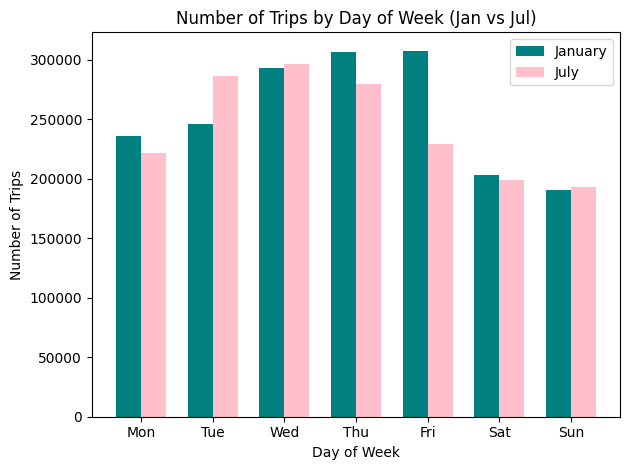

In [ ]:
#Vis1
df["day_of_week"] = df["service_date"].dt.dayofweek
day_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
daily_count = df.groupby(["month","day_of_week"])["trip_id"].count().unstack()

x = np.arange(len(day_names))
width = 0.35

plt.bar(x - width/2, daily_count.loc["January"], width=width, label="January", color='teal')
plt.bar(x + width/2, daily_count.loc["July"], width=width, label="July", color='pink')

plt.xticks(x, day_names)
plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.title("Number of Trips by Day of Week (Jan vs Jul)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#Day of week counts
daily_count = df.groupby(["month","day_of_week"])["trip_id"].count().unstack()
day_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
daily_count.columns = day_names

print(daily_count)


            Mon     Tue     Wed     Thu     Fri     Sat     Sun
month                                                          
January  235724  245952  292572  306101  307463  202626  190158
July     221652  286239  296619  279379  228959  199214  193202


<Figure size 600x500 with 0 Axes>

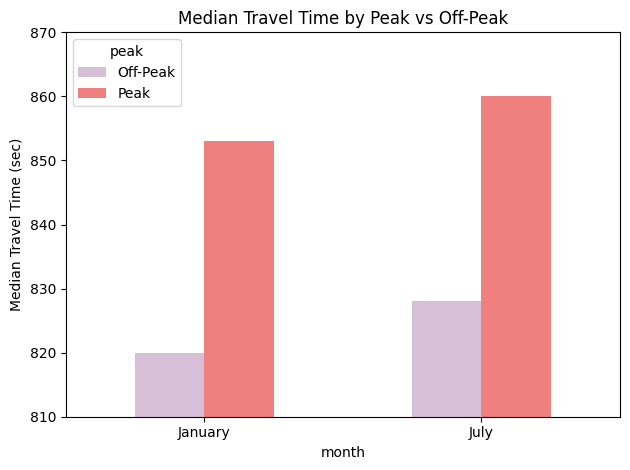

In [ ]:
#Vis2
medians = df.groupby(["month","peak"])["travel_time_sec"].median().unstack()

plt.figure(figsize=(6,5))
medians.plot(kind='bar', color=['thistle','lightcoral'])
plt.ylabel("Median Travel Time (sec)")
plt.title("Median Travel Time by Peak vs Off-Peak")
plt.xticks(rotation=0)

#Zoom
y_min = medians.min().min() - 10
y_max = medians.max().max() + 10
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()


In [ ]:
df.groupby(["month","peak"])["travel_time_sec"].median()

month    peak    
January  Off-Peak    820.0
         Peak        853.0
July     Off-Peak    828.0
         Peak        860.0
Name: travel_time_sec, dtype: float64

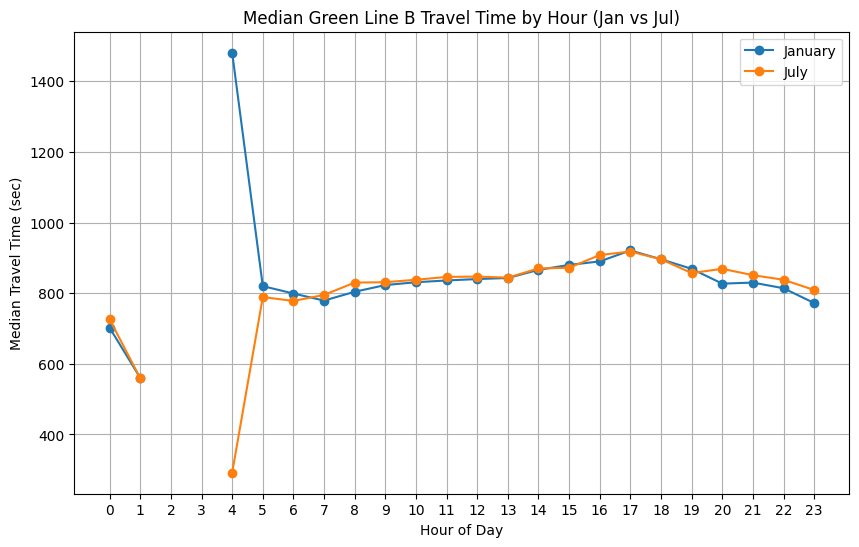

In [ ]:
#Vis3

jan_med_by_hour = df[df["month"]=="January"].groupby("hour")["travel_time_sec"].median()
jul_med_by_hour = df[df["month"]=="July"].groupby("hour")["travel_time_sec"].median()

#So missing hours appear as NaN
all_hours = np.arange(24)
jan_med_full = jan_med_by_hour.reindex(all_hours)
jul_med_full = jul_med_by_hour.reindex(all_hours)

plt.figure(figsize=(10,6))
plt.plot(all_hours, jan_med_full.values, label='January', marker='o')
plt.plot(all_hours, jul_med_full.values, label='July', marker='o')

plt.xlabel("Hour of Day")
plt.ylabel("Median Travel Time (sec)")
plt.title("Median Green Line B Travel Time by Hour (Jan vs Jul)")
plt.xticks(range(0,24))
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#January
jan_by_hour = df[df["month"]=="January"].groupby("hour")["travel_time_sec"].median()
print("January median travel time by hour:")
print(jan_by_hour)

#July
jul_by_hour = df[df["month"]=="July"].groupby("hour")["travel_time_sec"].median()
print("\nJuly median travel time by hour:")
print(jul_by_hour)


January median travel time by hour:
hour
0      702.0
1      560.0
4     1481.0
5      820.0
6      799.0
7      779.0
8      804.0
9      823.0
10     831.0
11     836.0
12     840.0
13     843.0
14     866.0
15     880.0
16     890.0
17     921.0
18     896.0
19     869.0
20     827.0
21     830.0
22     814.0
23     772.0
Name: travel_time_sec, dtype: float64

July median travel time by hour:
hour
0     726.0
1     559.0
4     291.5
5     789.0
6     778.0
7     795.0
8     830.0
9     831.0
10    838.0
11    846.0
12    847.0
13    844.0
14    870.0
15    872.0
16    908.0
17    918.0
18    896.0
19    857.0
20    869.0
21    851.0
22    838.0
23    809.0
Name: travel_time_sec, dtype: float64


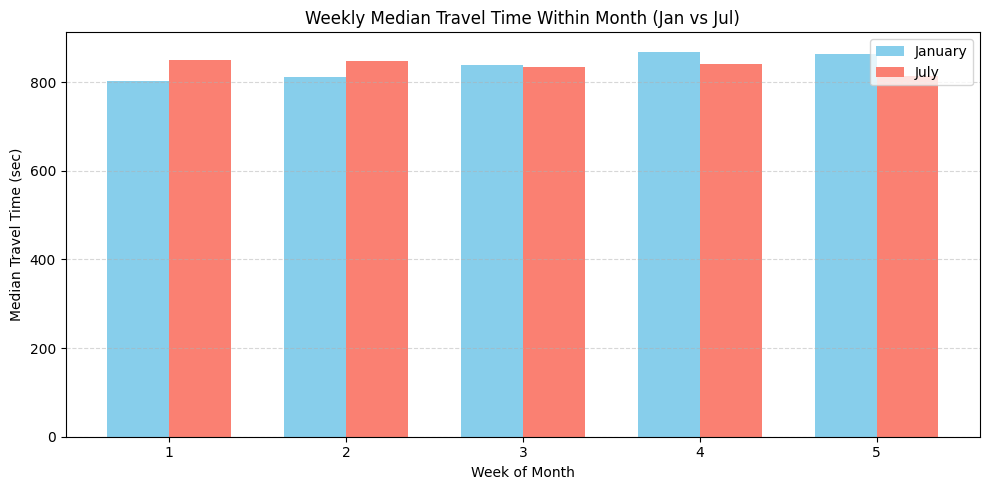

In [ ]:
#Vis4
df["week_in_month"] = ((df["service_date"].dt.day - 1) // 7) + 1
weekly_median = df.groupby(["month", "week_in_month"])["travel_time_sec"].median().unstack()

plt.figure(figsize=(10,5))
weeks = weekly_median.columns
width = 0.35

plt.bar(weeks - width/2, weekly_median.loc["January"], width=width, label="January", color='skyblue')
plt.bar(weeks + width/2, weekly_median.loc["July"], width=width, label="July", color='salmon')

plt.xlabel("Week of Month")
plt.ylabel("Median Travel Time (sec)")
plt.title("Weekly Median Travel Time Within Month (Jan vs Jul)")
plt.xticks(weeks)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
print(weekly_median)
weekly_counts = df.groupby(["month","week_in_month"])["travel_time_sec"].count().unstack()
print(weekly_counts)
weekly_stats = df.groupby(["month","week_in_month"])["travel_time_sec"].agg(['min','median','mean','max']).unstack()
print(weekly_stats)

week_in_month      1      2      3      4      5
month                                           
January        803.0  811.0  838.0  869.0  863.0
July           849.0  847.0  835.0  840.0  813.0
week_in_month       1       2       3       4       5
month                                                
January        400878  413508  386475  395975  183760
July           367492  383444  380905  390634  182789
              min                 median                              \
week_in_month   1   2   3   4   5      1      2      3      4      5   
month                                                                  
January        60  60  60  60  60  803.0  811.0  838.0  869.0  863.0   
July           60  60  60  60  60  849.0  847.0  835.0  840.0  813.0   

                     mean                                                    \
week_in_month           1           2           3            4            5   
month                                                                

Observed Difference: -11.302383460331953
95% CI: -12.7709920149553 -9.864553350390562


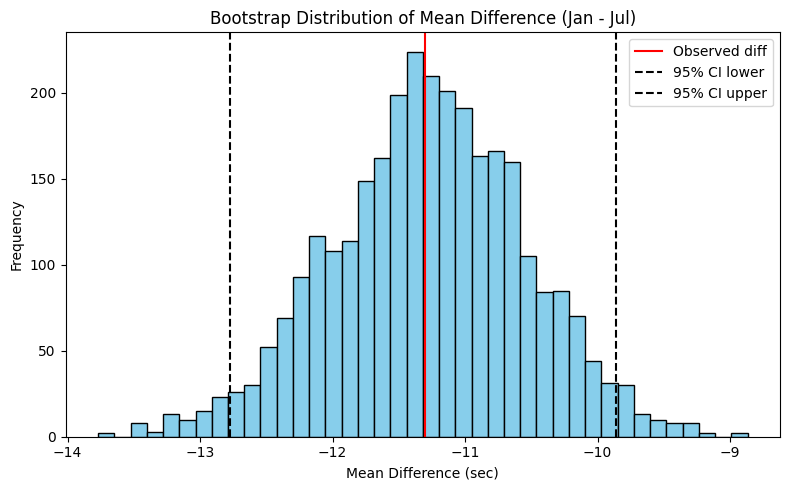

In [ ]:
#Hypothesis Test

jan = df[df["month"] == "January"]["travel_time_sec"]
jul = df[df["month"] == "July"]["travel_time_sec"]

#Observed difference in means
obs_diff = jan.mean() - jul.mean()

#Bootstrap
boot_diffs = []
n_boot = 3000

for _ in range(n_boot):
    boot_jan = jan.sample(frac=1, replace=True)
    boot_jul = jul.sample(frac=1, replace=True)
    boot_diffs.append(boot_jan.mean() - boot_jul.mean())

boot_diffs = np.array(boot_diffs)

#95% confidence interval
ci_lower, ci_upper = np.percentile(boot_diffs, [2.5, 97.5])

print("Observed Difference:", obs_diff)
print("95% CI:", ci_lower, ci_upper)

plt.figure(figsize=(8,5))
plt.hist(boot_diffs, bins=40, color="skyblue", edgecolor="black")
plt.axvline(obs_diff, color="red", label="Observed diff")
plt.axvline(ci_lower, color="black", linestyle="--", label="95% CI lower")
plt.axvline(ci_upper, color="black", linestyle="--", label="95% CI upper")
plt.xlabel("Mean Difference (sec)")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Mean Difference (Jan - Jul)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
print(sorted(df.columns))

['day', 'day_of_week', 'direction', 'direction_id', 'from_parent_station', 'from_stop_departure_datetime', 'from_stop_departure_sec', 'from_stop_id', 'from_stop_name', 'hour', 'is_january', 'is_peak', 'month', 'peak', 'route_id', 'service_date', 'to_parent_station', 'to_stop_arrival_datetime', 'to_stop_arrival_sec', 'to_stop_id', 'to_stop_name', 'travel_time_sec', 'trip_id', 'week_in_month']


In [ ]:
#Linear Regression
# Set up variables

y_col = "travel_time_sec"

# Create dummy variables, January = 1, July = 0; Peak = 1, Off-Peak = 0
df["is_january"] = (df["month"] == "January").astype(int)
df["is_peak"] = (df["peak"] == "Peak").astype(int)

reg_df = df[[y_col, "is_january", "is_peak"]].dropna()

Y_mean = np.mean(reg_df[y_col])
Y_std  = np.std(reg_df[y_col])

X1_mean = np.mean(reg_df["is_january"])
X1_std  = np.std(reg_df["is_january"])

X2_mean = np.mean(reg_df["is_peak"])
X2_std  = np.std(reg_df["is_peak"])
corr_jan = np.corrcoef(reg_df["is_january"], reg_df[y_col])[0, 1]
corr_peak = np.corrcoef(reg_df["is_peak"], reg_df[y_col])[0, 1]

print("Summary statistics for regression variables")
print(f"Average travel time: {Y_mean:.2f} sec")
print(f"Std dev of travel time: {Y_std:.2f} sec\n")

print(f"January indicator – mean: {X1_mean:.2f}, std: {X1_std:.2f}")
print(f"Correlation with travel time: {corr_jan:.3f}\n")

print(f"Peak indicator – mean: {X2_mean:.2f}, std: {X2_std:.2f}")
print(f"Correlation with travel time: {corr_peak:.3f}")

print(f"\nObservations used: {len(reg_df)}")


Summary statistics for regression variables
Average travel time: 968.34 sec
Std dev of travel time: 677.02 sec

January indicator – mean: 0.51, std: 0.50
Correlation with travel time: -0.008

Peak indicator – mean: 0.37, std: 0.48
Correlation with travel time: 0.027

Observations used: 3485860


In [ ]:
import statsmodels.formula.api as smf

model = smf.ols("travel_time_sec ~ is_january + is_peak", data=reg_df).fit()
print(model.summary())

print("\nHypothesis test for January effect (controlling for peak):")
print("H0: beta_is_january = 0")
print("coef   =", model.params["is_january"])
print("p-value=", model.pvalues["is_january"])

                            OLS Regression Results                            
Dep. Variable:        travel_time_sec   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1423.
Date:                Tue, 16 Dec 2025   Prob (F-statistic):               0.00
Time:                        16:53:30   Log-Likelihood:            -2.7665e+07
No. Observations:             3485860   AIC:                         5.533e+07
Df Residuals:                 3485857   BIC:                         5.533e+07
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    960.1549      0.586   1638.269      0.0

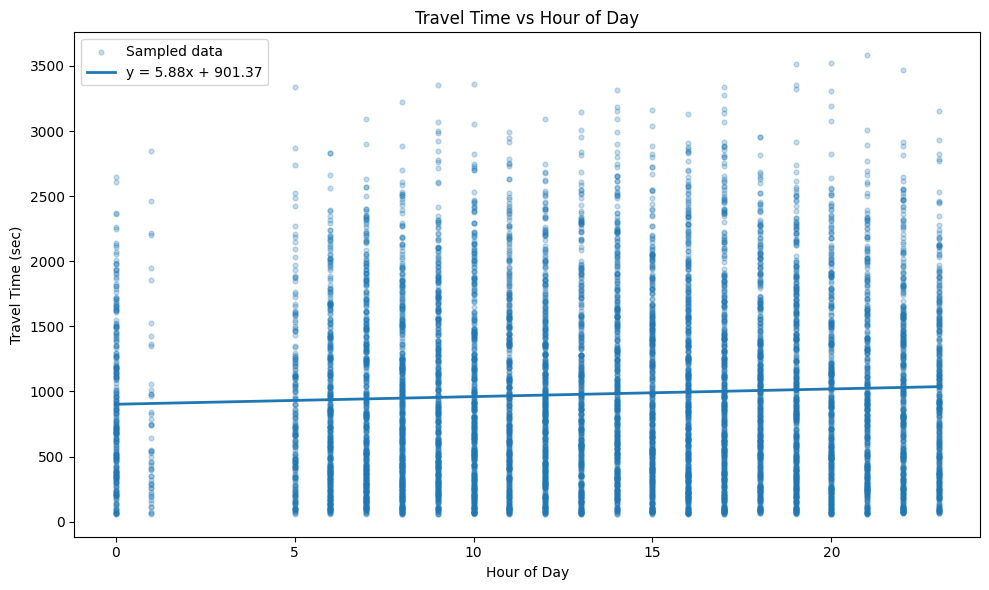

Fitted line:
travel_time_sec = (5.8755) * hour + (901.3741)


In [ ]:
#Travel time vs hour of day with a regression line

x_col = "hour"
y_col = "travel_time_sec"

#Keep only the rows that are valid
tmp = df[[x_col, y_col]].dropna()
tmp = tmp[(tmp[x_col] >= 0) & (tmp[x_col] <= 23)]

#Sample
n = 8000
plot_df = tmp.sample(n=min(n, len(tmp)), random_state=42)

x = plot_df[x_col].to_numpy()
y = plot_df[y_col].to_numpy()

#y = m*x + b
m, b = np.polyfit(x, y, 1)


x_line = np.linspace(0, 23, 200)
y_line = m * x_line + b

#Scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.25, s=12, label="Sampled data")
plt.plot(x_line, y_line, linewidth=2, label=f"y = {m:.2f}x + {b:.2f}")

plt.xlabel("Hour of Day")
plt.ylabel("Travel Time (sec)")
plt.title("Travel Time vs Hour of Day")
plt.legend()
plt.tight_layout()
plt.show()

print("Fitted line:")
print(f"{y_col} = ({m:.4f}) * {x_col} + ({b:.4f})")


In [ ]:
df.head()

,service_date,route_id,trip_id,direction_id,direction,from_parent_station,from_stop_id,from_stop_name,to_parent_station,to_stop_id,...,to_stop_arrival_sec,travel_time_sec,month,hour,day,peak,day_of_week,week_in_month,is_january,is_peak
0,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-pktrm,70196,...,21885,77,January,6,1,Off-Peak,2,1,1,0
1,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-boyls,70159,...,21989,181,January,6,1,Off-Peak,2,1,1,0
2,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-armnl,70157,...,22128,320,January,6,1,Off-Peak,2,1,1,0
3,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-coecl,70155,...,22222,414,January,6,1,Off-Peak,2,1,1,0
4,2025-01-01,Green-B,66821738,0,West,place-gover,70202,Government Center,place-hymnl,70153,...,22381,573,January,6,1,Off-Peak,2,1,1,0


In [ ]:
from sklearn.linear_model import LinearRegression

# X = predictors, y = response
X = reg_df[["is_january", "is_peak"]]
y = reg_df[y_col]

model = LinearRegression()
model.fit(X, y)

r2 = model.score(X, y)
b0 = model.intercept_
b1, b2 = model.coef_

print(f"Regression equation: {y_col} = {b0:.2f} + ({b1:.2f})*is_january + ({b2:.2f})*is_peak")
print(f"R^2: {r2:.4f}")

Regression equation: travel_time_sec = 960.15 + (-11.62)*is_january + (38.33)*is_peak
R^2: 0.0008
